# Testing `hetmacro.quadrature`

This notebook exercises each quadrature rule in `hetmacro/quadrature.py`, reproduces the slide example (joint normal → lognormal moment), and adds additional tests to compare accuracy and the curse of dimensionality.

In [17]:
import sys
from pathlib import Path
import time

import numpy as np
import matplotlib.pyplot as plt
from scipy import special

# Add project root to path for local imports
repo_root = Path.cwd().parents[1]
if str(repo_root) not in sys.path:
    sys.path.append(str(repo_root))

from hetmacro.quadrature import (
    qnwlege,
    qnwcheb,
    qnwnorm,
    qnwlogn,
    qnwunif,
    qnwsimp,
    qnwtrap,
    qnwbeta,
    qnwgamma,
    qnwnorm_mv,
)

plt.rcParams.update({"figure.figsize": (8, 4), "axes.grid": True})


def quad_expectation(nodes, weights, f):
    vals = f(nodes)
    return np.sum(weights * vals)


def print_table(rows, headers):
    rows_str = [[str(v) for v in row] for row in rows]
    widths = [len(h) for h in headers]
    for row in rows_str:
        for i, val in enumerate(row):
            widths[i] = max(widths[i], len(val))
    fmt = "  ".join([f"{{:{w}}}" for w in widths])
    print(fmt.format(*headers))
    print(fmt.format(*["-" * w for w in widths]))
    for row in rows_str:
        print(fmt.format(*row))


print("Packages and modules loaded successfully!")

Packages and modules loaded successfully!


## 1. Gauss-Legendre on [0, 1]

Gauss-Legendre integrates polynomials of degree up to `2n-1` exactly.

In [18]:
def f_poly(x):
    return x**5

exact = 1.0 / 6.0
ns = [2, 3, 4, 5]
rows = []
for n in ns:
    x, w = qnwlege(n, 0.0, 1.0)
    est = quad_expectation(x, w, f_poly)
    rows.append([n, f"{est:.10f}", f"{abs(est - exact):.2e}"])

print_table(rows, ["n", "estimate", "abs error"])

n  estimate      abs error
-  ------------  ---------
2  0.1527777778  1.39e-02 
3  0.1666666667  0.00e+00 
4  0.1666666667  8.33e-17 
5  0.1666666667  2.78e-17 


## 2. Gauss-Chebyshev on [-1, 1]

Chebyshev weights correspond to the weight function `w(x) = 1 / sqrt(1 - x^2)`.

In [19]:
def f_const(x):
    return np.ones_like(x)

def f_x2(x):
    return x**2

n = 10
x, w = qnwcheb(n, -1.0, 1.0)

est_const = quad_expectation(x, w, f_const)
est_x2 = quad_expectation(x, w, f_x2)

print(f"E_w[1] ≈ {est_const:.8f} (exact: {np.pi:.8f})")
print(f"E_w[x^2] ≈ {est_x2:.8f} (exact: {0.5 * np.pi:.8f})")

E_w[1] ≈ 3.14159265 (exact: 3.14159265)
E_w[x^2] ≈ 1.57079633 (exact: 1.57079633)


## 3. Normal and lognormal expectations

In [20]:
mu, sigma, n = 0.5, 1.2, 7

# Normal: E[X^2] = mu^2 + sigma^2
x, w = qnwnorm(n, mu, sigma)
est_x2 = quad_expectation(x, w, lambda z: z**2)
exact_x2 = mu**2 + sigma**2

# Lognormal: E[exp(X)] = exp(mu + 0.5 * sigma^2)
x_ln, w_ln = qnwlogn(n, mu, sigma)
est_ln = quad_expectation(x_ln, w_ln, lambda z: z)
exact_ln = np.exp(mu + 0.5 * sigma**2)

print(f"Normal E[X^2] ≈ {est_x2:.8f} (exact: {exact_x2:.8f})")
print(f"Lognormal E[X] ≈ {est_ln:.8f} (exact: {exact_ln:.8f})")

Normal E[X^2] ≈ 1.69000000 (exact: 1.69000000)
Lognormal E[X] ≈ 3.38718601 (exact: 3.38718773)


## 4. Uniform expectations

In [21]:
a, b, n = 0.0, 2.0, 9
x, w = qnwunif(n, a, b)

est_x = quad_expectation(x, w, lambda z: z)
est_x2 = quad_expectation(x, w, lambda z: z**2)

exact_x = 0.5 * (a + b)
exact_x2 = (a**2 + a * b + b**2) / 3.0

print(f"Uniform E[X] ≈ {est_x:.8f} (exact: {exact_x:.8f})")
print(f"Uniform E[X^2] ≈ {est_x2:.8f} (exact: {exact_x2:.8f})")

Uniform E[X] ≈ 1.00000000 (exact: 1.00000000)
Uniform E[X^2] ≈ 1.33333333 (exact: 1.33333333)


## 5. Simpson vs trapezoid (non-Gaussian rules)

In [22]:
def integrate_rule(rule, n):
    x, w = rule(n, 0.0, np.pi)
    return np.sum(w * np.sin(x))

exact = 2.0
ns = [5, 9, 17, 33, 65]
rows = []
for n in ns:
    est_simp = integrate_rule(qnwsimp, n)
    est_trap = integrate_rule(qnwtrap, n)
    rows.append([
        n,
        f"{est_simp:.8f}",
        f"{abs(est_simp - exact):.2e}",
        f"{est_trap:.8f}",
        f"{abs(est_trap - exact):.2e}",
    ])

print_table(rows, ["n", "Simpson", "Simpson err", "Trap", "Trap err"])

n   Simpson     Simpson err  Trap        Trap err
--  ----------  -----------  ----------  --------
5   2.00455975  4.56e-03     1.89611890  1.04e-01
9   2.00026917  2.69e-04     1.97423160  2.58e-02
17  2.00001659  1.66e-05     1.99357034  6.43e-03
33  2.00000103  1.03e-06     1.99839336  1.61e-03
65  2.00000006  6.45e-08     1.99959839  4.02e-04


## 6. Beta and Gamma expectations

In [23]:
# Beta(a, b) on [0, 1]
a, b, n = 2.0, 5.0, 9
x, w = qnwbeta(n, a, b)
est_beta = quad_expectation(x, w, lambda z: z)
exact_beta = a / (a + b)

# Gamma(a, b) with shape a and scale b
a_g, b_g, n = 2.0, 3.0, 9
xg, wg = qnwgamma(n, a_g, b_g)
est_gamma = quad_expectation(xg, wg, lambda z: z)
exact_gamma = a_g * b_g

print(f"Beta E[X] ≈ {est_beta:.8f} (exact: {exact_beta:.8f})")
print(f"Gamma E[X] ≈ {est_gamma:.8f} (exact: {exact_gamma:.8f})")

Beta E[X] ≈ 0.76190476 (exact: 0.28571429)
Gamma E[X] ≈ 6.00000000 (exact: 6.00000000)


## 7. Multivariate normal (slide example)

Compute `E[exp(x - 2y)]` for jointly normal `(x, y)` and compare with the analytical moment.

In [24]:
n = np.array([7, 7])
mu = np.array([0.1, 0.2])
Sigma = np.array([[0.2, 0.1], [0.1, 0.3]])

nodes, weights = qnwnorm_mv(n, mu, Sigma)
est = quad_expectation(nodes, weights, lambda z: np.exp(z[:, 0] - 2.0 * z[:, 1]))

a = np.array([1.0, -2.0])
exact = np.exp(a @ mu + 0.5 * (a @ Sigma @ a))

print(f"Quadrature ≈ {est:.8f}")
print(f"Exact      = {exact:.8f}")

Quadrature ≈ 1.22140270
Exact      = 1.22140276


## 8. Curse of dimensionality: tensor-product normal

We hold the number of nodes per dimension fixed and observe the growth in total nodes and error.

In [25]:
def f_exp_sum(nodes):
    if nodes.ndim == 1:
        return np.exp(nodes)
    return np.exp(np.sum(nodes, axis=1))

rows = []
n_per_dim = 5
for d in [1, 2, 3, 4]:
    n = np.full(d, n_per_dim)
    mu = np.zeros(d)
    Sigma = np.eye(d)
    nodes, weights = qnwnorm_mv(n, mu, Sigma)

    est = quad_expectation(nodes, weights, f_exp_sum)
    exact = np.exp(0.5 * d)
    err = abs(est - exact)

    rows.append([
        d,
        n_per_dim ** d,
        f"{est:.8f}",
        f"{err:.2e}",
    ])

print_table(rows, ["dim", "nodes", "estimate", "abs error"])

dim  nodes  estimate    abs error
---  -----  ----------  ---------
1    5      1.64867943  4.18e-05 
2    25     2.71814386  1.38e-04 
3    125    4.48134786  3.41e-04 
4    625    7.38830603  7.50e-04 


## 9. Timing: how cost scales with dimension

In [26]:
rows = []
reps = 3
n_per_dim = 5
for d in [1, 2, 3, 4]:
    n = np.full(d, n_per_dim)
    mu = np.zeros(d)
    Sigma = np.eye(d)

    start = time.perf_counter()
    for _ in range(reps):
        nodes, weights = qnwnorm_mv(n, mu, Sigma)
        _ = quad_expectation(nodes, weights, f_exp_sum)
    elapsed = (time.perf_counter() - start) / reps

    rows.append([d, n_per_dim ** d, f"{elapsed:.6f}"])

print_table(rows, ["dim", "nodes", "avg seconds"])

dim  nodes  avg seconds
---  -----  -----------
1    5      0.000127   
2    25     0.000386   
3    125    0.000331   
4    625    0.000447   


## 10. Visual checks: comprehensive subplot figure

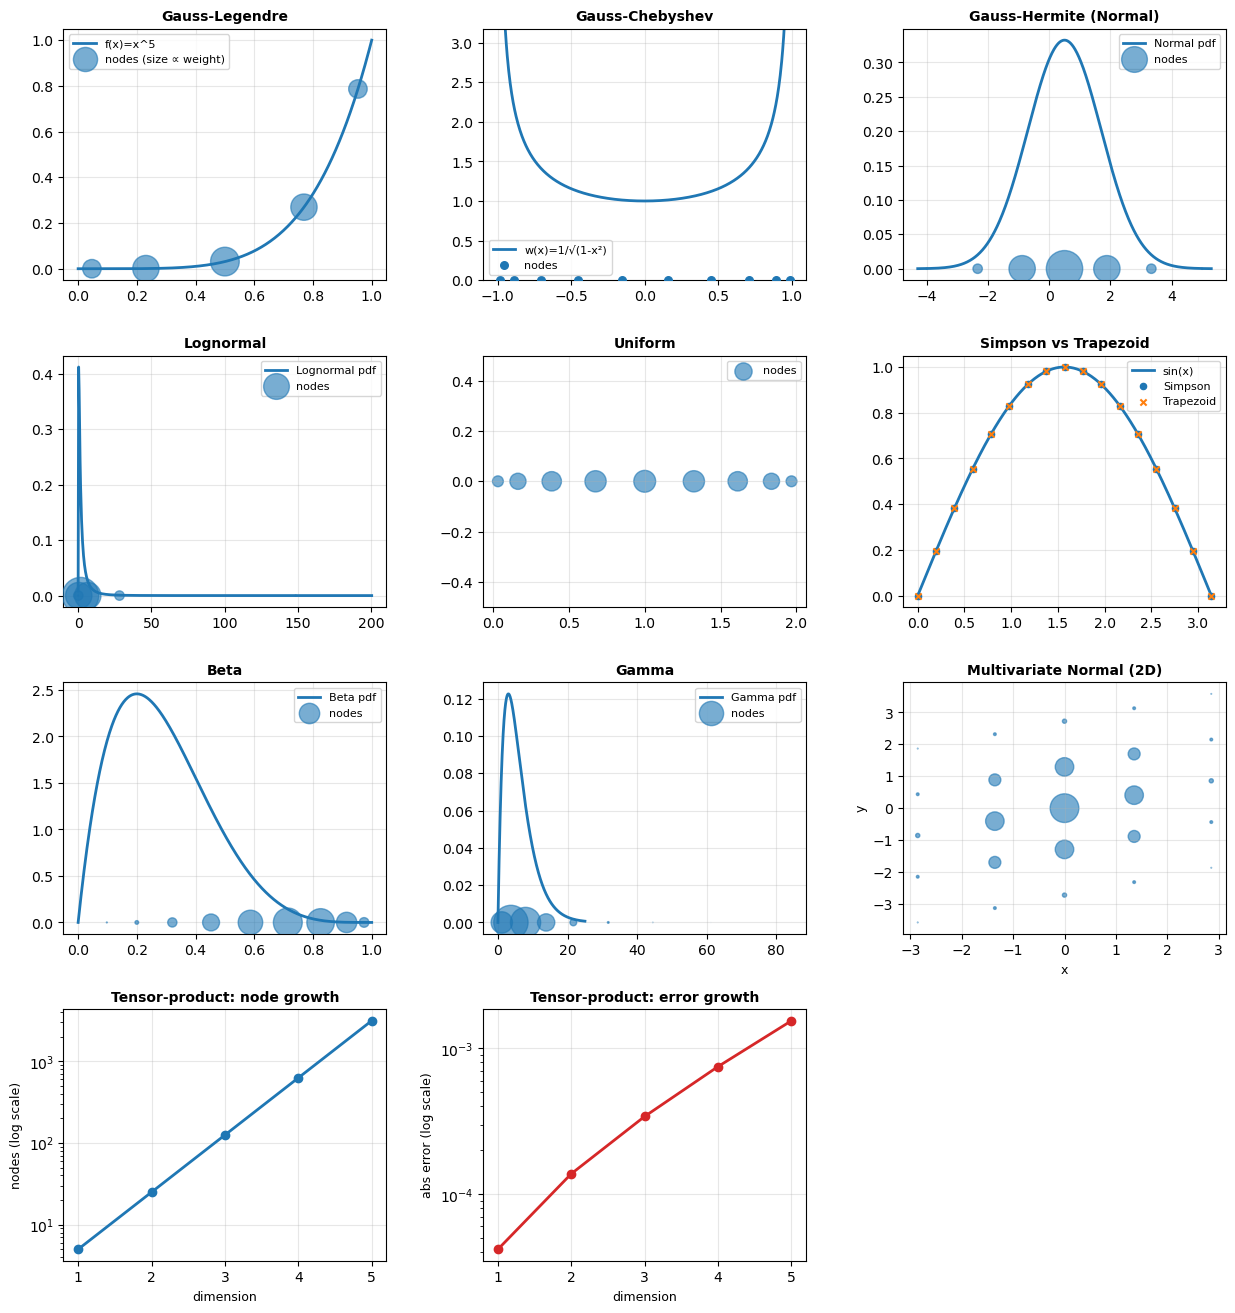

In [28]:
# Create comprehensive visualization with all quadrature rules in one figure

fig = plt.figure(figsize=(15, 16))
gs = fig.add_gridspec(4, 3, hspace=0.3, wspace=0.3)

# 1. Gauss-Legendre nodes/weights on [0, 1]
ax1 = fig.add_subplot(gs[0, 0])
n = 5
x, w = qnwlege(n, 0.0, 1.0)
xx = np.linspace(0.0, 1.0, 400)
ax1.plot(xx, f_poly(xx), label="f(x)=x^5", linewidth=2)
ax1.scatter(x, f_poly(x), s=1500 * w, label="nodes (size ∝ weight)", zorder=3, alpha=0.6)
ax1.set_title("Gauss-Legendre", fontsize=10, fontweight="bold")
ax1.legend(fontsize=8)
ax1.grid(True, alpha=0.3)

# 2. Gauss-Chebyshev nodes and weight function on [-1, 1]
ax2 = fig.add_subplot(gs[0, 1])
n = 10
x, w = qnwcheb(n, -1.0, 1.0)
xx = np.linspace(-0.999, 0.999, 600)
weight_fun = 1.0 / np.sqrt(1.0 - xx**2)
ax2.plot(xx, weight_fun, label="w(x)=1/√(1-x²)", linewidth=2)
ax2.scatter(x, np.zeros_like(x), s=30, label="nodes", zorder=3)
ax2.set_ylim(0, np.percentile(weight_fun, 95))
ax2.set_title("Gauss-Chebyshev", fontsize=10, fontweight="bold")
ax2.legend(fontsize=8)
ax2.grid(True, alpha=0.3)

# 3. Normal pdf with nodes/weights
ax3 = fig.add_subplot(gs[0, 2])
mu, sigma, n = 0.5, 1.2, 7
xn, wn = qnwnorm(n, mu, sigma)
xx = np.linspace(mu - 4 * sigma, mu + 4 * sigma, 600)
pdf_n = (1.0 / (sigma * np.sqrt(2 * np.pi))) * np.exp(-0.5 * ((xx - mu) / sigma) ** 2)
ax3.plot(xx, pdf_n, label="Normal pdf", linewidth=2)
ax3.scatter(xn, np.zeros_like(xn), s=1500 * wn, label="nodes", zorder=3, alpha=0.6)
ax3.set_title("Gauss-Hermite (Normal)", fontsize=10, fontweight="bold")
ax3.legend(fontsize=8)
ax3.grid(True, alpha=0.3)

# 4. Lognormal pdf with nodes/weights
ax4 = fig.add_subplot(gs[1, 0])
xl, wl = qnwlogn(n, mu, sigma)
xx = np.linspace(np.exp(mu - 4 * sigma), np.exp(mu + 4 * sigma), 600)
pdf_ln = (1.0 / (xx * sigma * np.sqrt(2 * np.pi))) * np.exp(-0.5 * ((np.log(xx) - mu) / sigma) ** 2)
ax4.plot(xx, pdf_ln, label="Lognormal pdf", linewidth=2)
ax4.scatter(xl, np.zeros_like(xl), s=1500 * wl, label="nodes", zorder=3, alpha=0.6)
ax4.set_title("Lognormal", fontsize=10, fontweight="bold")
ax4.legend(fontsize=8)
ax4.grid(True, alpha=0.3)

# 5. Uniform nodes and weights
ax5 = fig.add_subplot(gs[1, 1])
a, b, n = 0.0, 2.0, 9
xu, wu = qnwunif(n, a, b)
ax5.scatter(xu, np.zeros_like(xu), s=1500 * wu, label="nodes", alpha=0.6)
ax5.set_ylim(-0.5, 0.5)
ax5.set_title("Uniform", fontsize=10, fontweight="bold")
ax5.legend(fontsize=8)
ax5.grid(True, alpha=0.3)

# 6. Simpson vs trapezoid on sin(x)
ax6 = fig.add_subplot(gs[1, 2])
xs, ws = qnwsimp(17, 0.0, np.pi)
xt, wt = qnwtrap(17, 0.0, np.pi)
xx = np.linspace(0.0, np.pi, 400)
ax6.plot(xx, np.sin(xx), label="sin(x)", linewidth=2)
ax6.scatter(xs, np.sin(xs), s=20, label="Simpson", zorder=3)
ax6.scatter(xt, np.sin(xt), s=20, marker="x", label="Trapezoid", zorder=3)
ax6.set_title("Simpson vs Trapezoid", fontsize=10, fontweight="bold")
ax6.legend(fontsize=8)
ax6.grid(True, alpha=0.3)

# 7. Beta pdf with nodes/weights
ax7 = fig.add_subplot(gs[2, 0])
a, b, n = 2.0, 5.0, 9
xb, wb = qnwbeta(n, a, b)
xx = np.linspace(0.0, 1.0, 600)
pdf_beta = (xx ** (a - 1) * (1 - xx) ** (b - 1)) / np.trapz(xx ** (a - 1) * (1 - xx) ** (b - 1), xx)
ax7.plot(xx, pdf_beta, label="Beta pdf", linewidth=2)
ax7.scatter(xb, np.zeros_like(xb), s=1500 * wb, label="nodes", zorder=3, alpha=0.6)
ax7.set_title("Beta", fontsize=10, fontweight="bold")
ax7.legend(fontsize=8)
ax7.grid(True, alpha=0.3)

# 8. Gamma pdf with nodes/weights
ax8 = fig.add_subplot(gs[2, 1])
a_g, b_g, n = 2.0, 3.0, 9
xg, wg = qnwgamma(n, a_g, b_g)
xx = np.linspace(0.0, 25.0, 600)
pdf_gamma = (xx ** (a_g - 1) * np.exp(-xx / b_g)) / (b_g ** a_g * special.gamma(a_g))
ax8.plot(xx, pdf_gamma, label="Gamma pdf", linewidth=2)
ax8.scatter(xg, np.zeros_like(xg), s=1500 * wg, label="nodes", zorder=3, alpha=0.6)
ax8.set_title("Gamma", fontsize=10, fontweight="bold")
ax8.legend(fontsize=8)
ax8.grid(True, alpha=0.3)

# 9. Multivariate normal nodes (2D)
ax9 = fig.add_subplot(gs[2, 2])
n = np.array([5, 5])
mu = np.array([0.0, 0.0])
Sigma = np.array([[1.0, 0.3], [0.3, 1.0]])
nodes, weights = qnwnorm_mv(n, mu, Sigma)
ax9.scatter(nodes[:, 0], nodes[:, 1], s=1500 * weights, alpha=0.6)
ax9.set_title("Multivariate Normal (2D)", fontsize=10, fontweight="bold")
ax9.set_xlabel("x", fontsize=9)
ax9.set_ylabel("y", fontsize=9)
ax9.grid(True, alpha=0.3)

# 10. Curse of dimensionality: nodes vs dimension
ax10 = fig.add_subplot(gs[3, 0])
rows = []
n_per_dim = 5
for d in [1, 2, 3, 4, 5]:
    n = np.full(d, n_per_dim)
    mu = np.zeros(d)
    Sigma = np.eye(d)
    nodes, weights = qnwnorm_mv(n, mu, Sigma)
    est = quad_expectation(nodes, weights, f_exp_sum)
    exact = np.exp(0.5 * d)
    rows.append([d, n_per_dim ** d, abs(est - exact)])

rows = np.array(rows)
ax10.plot(rows[:, 0], rows[:, 1], marker="o", linewidth=2, color="tab:blue")
ax10.set_yscale("log")
ax10.set_xlabel("dimension", fontsize=9)
ax10.set_ylabel("nodes (log scale)", fontsize=9)
ax10.set_title("Tensor-product: node growth", fontsize=10, fontweight="bold")
ax10.grid(True, alpha=0.3)

# 11. Curse of dimensionality: error vs dimension
ax11 = fig.add_subplot(gs[3, 1])
ax11.plot(rows[:, 0], rows[:, 2], marker="o", linewidth=2, color="tab:red")
ax11.set_yscale("log")
ax11.set_xlabel("dimension", fontsize=9)
ax11.set_ylabel("abs error (log scale)", fontsize=9)
ax11.set_title("Tensor-product: error growth", fontsize=10, fontweight="bold")
ax11.grid(True, alpha=0.3)

# Hide the last unused subplot
ax12 = fig.add_subplot(gs[3, 2])
ax12.axis("off")

# plt.suptitle("Quadrature Rules: Visual Verification", fontsize=16, fontweight="bold", y=0.995)
plt.show()